In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    'grid.linestyle':    '--',
    'grid.linewidth':    0.4,
    'axes.linewidth':   0.8,
})

def bootstrap_ci_width(x, n_resamples=10):
    """Return upper 95% bootstrap CI distance from the mean."""
    result = stats.bootstrap(
        (x.dropna().values,),
        np.mean,
        confidence_level=0.95,
        n_resamples=n_resamples,
        random_state=1,
        method="percentile",
    )
    mean = np.mean(x)
    return result.confidence_interval.high - mean


def clean_axis(ax, xlabel="", ylabel=""):
    """Apply minimal Nature-style axis formatting."""
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(direction="out", length=4, width=1.1)

# Load data

In [2]:
df1 = pd.read_parquet("data_first_au.parquet")
df2 = pd.read_parquet("data_last_au.parquet")
# df['ai_prob_'] = pd.cut(df['ai_prob'], bins=10).apply(lambda x:x.mid)

In [3]:
for col in ["cit", "CD", "Novelty"]:

    df1[f"{col}_pct"] = (
        df1
        .groupby("Year")[col]
        .rank(pct=True)
        * 100
    )

    df2[f"{col}_pct"] = (
        df2
        .groupby("Year")[col]
        .rank(pct=True)
        * 100
    )

In [4]:
df1.columns

Index(['PaperID', 'AIProb', 'Year', 'SourceID', 'first_age', 'first_Female',
       'first_country', 'first_institution_tier', 'first_h_index',
       'first_Productivity', 'team_size', 'Age_gini', 'Gender_entropy',
       'cit_pct', 'cit', 'n_ref', 'CD', 'Novelty', 'JIF', 'JIF_Quartile',
       'Inter_national', 'Multi_field', 'Gender_P', 'CD_pct', 'Novelty_pct'],
      dtype='object')

In [5]:
colors = {
    "Female": "#CC79A7",
    "Male": "#0072B2"
}

markers = {
    "Female": "o",
    "Male": "s"
}


def clean_axis(ax, xlabel="", ylabel=""):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def prepare_ai_bin_df(df, gender_col):
    d = df.copy()

    d = d[d[gender_col].isin([0, 1, 0.0, 1.0])].copy()
    d["Gender"] = d[gender_col].map({1: "Female", 1.0: "Female", 0: "Male", 0.0: "Male"})

    # 如果 AIProb 是 0-100，先转回 0-1
    if d["AIProb"].max() > 1:
        d["AIProb_plot"] = d["AIProb"] / 100
    else:
        d["AIProb_plot"] = d["AIProb"]

    bins = np.arange(0, 1.0001, 0.1)
    labels = [f"{bins[i]:.1f}–{bins[i+1]:.1f}" for i in range(len(bins) - 1)]
    centers = (bins[:-1] + bins[1:]) / 2

    d["AIProb_bin"] = pd.cut(
        d["AIProb_plot"],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=False
    )

    # 把 AIProb == 1.0 放入最后一个 bin
    d.loc[d["AIProb_plot"] == 1.0, "AIProb_bin"] = labels[-1]

    bin_center_map = dict(zip(labels, centers))
    d["AIProb_center"] = d["AIProb_bin"].map(bin_center_map).astype(float)

    return d.dropna(subset=["AIProb_bin"])


def summarize_by_bin(d, outcome):
    s = (
        d.dropna(subset=[outcome])
         .groupby(["AIProb_center", "AIProb_bin", "Gender"], observed=True)
         .agg(
             mean=(outcome, "mean"),
             n=(outcome, "size"),
             sd=(outcome, "std")
         )
         .reset_index()
    )

    s["se"] = s["sd"] / np.sqrt(s["n"])
    s["low"] = s["mean"] - 1.96 * s["se"]
    s["high"] = s["mean"] + 1.96 * s["se"]

    return s


def draw_line(ax, d, outcome,title, ylabel):
    s = summarize_by_bin(d, outcome)

    for gender in ["Female", "Male"]:
        sub = s[s["Gender"] == gender].sort_values("AIProb_center")

        if sub.empty:
            continue

        ax.plot(
            sub["AIProb_center"],
            sub["mean"],
            marker=markers[gender],
            markersize=5,
            linewidth=1.2,
            color=colors[gender],
            label=gender
        )

        ax.fill_between(
            sub["AIProb_center"],
            sub["low"],
            sub["high"],
            color=colors[gender],
            alpha=0.15,
            linewidth=0
        )

    clean_axis(ax, xlabel="AI probability", ylabel=ylabel)
    ax.set_xticks(np.arange(0.05, 1.0, 0.1))
    ax.set_xticklabels([f"{x:.1f}" for x in np.arange(0.1, 1.1, 0.1)], rotation=45)
    ax.grid(axis="y", alpha=0.3)
    if i==0:
        ax.set_title(title)

# Prepare data
first_df = prepare_ai_bin_df(df1, gender_col="first_Female")
last_df = prepare_ai_bin_df(df2, gender_col="last_Female")

In [6]:
outcomes = [
    # ("cit_pct", "Citation pct"),
    ("Novelty_pct", "Novelty pct"),
    ("CD_pct", "Disruptiveness pct")
]

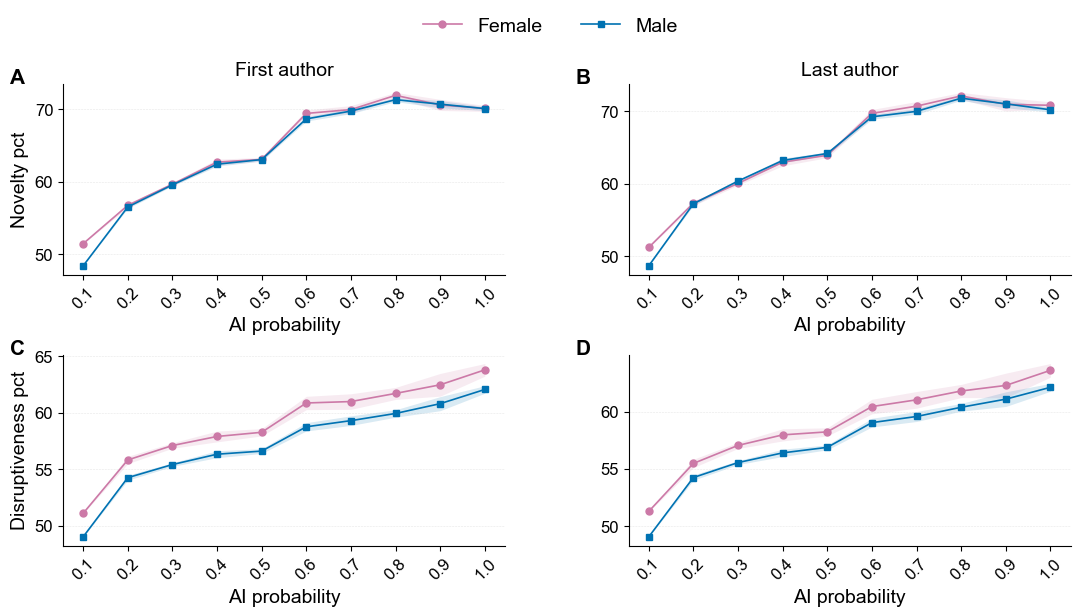

In [7]:
fig = plt.figure(figsize=(13, 6))

gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[1, 1],
    height_ratios=[1, 1],
    wspace=0.28,
    hspace=0.42
)

axes = []

for i, (outcome, ylabel) in enumerate(outcomes):
    ax_left = fig.add_subplot(gs[i, 0])
    ax_right = fig.add_subplot(gs[i, 1])

    draw_line(
        ax_left,
        first_df,
        outcome=outcome,
        title=f"First author",
        ylabel=ylabel
    )

    draw_line(
        ax_right,
        last_df,
        outcome=outcome,
        title=f"Last author",
        ylabel=""
    )
    axes.extend([ax_left, ax_right])


# Only keep one legend
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

fig.legend(
    handles,
    labels,
    frameon=False,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02)
)


# Panel labels
for ax, lab in zip(axes, list("ABCDEF")):
    ax.text(
        -0.12,
        1.08,
        lab,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top"
    )

plt.savefig("Data/fig4.pdf", bbox_inches="tight")

In [8]:
# fig = plt.figure(figsize=(13, 10))

# gs = gridspec.GridSpec(
#     3, 2,
#     width_ratios=[1, 1],
#     height_ratios=[1, 1, 1],
#     wspace=0.28,
#     hspace=0.42
# )

# axes = []

# for i, (outcome, ylabel) in enumerate(outcomes):
#     ax_left = fig.add_subplot(gs[i, 0])
#     ax_right = fig.add_subplot(gs[i, 1])

#     draw_line(
#         ax_left,
#         first_df,
#         outcome=outcome,
#         title=f"First author",
#         ylabel=ylabel
#     )

#     draw_line(
#         ax_right,
#         last_df,
#         outcome=outcome,
#         title=f"Last author",
#         ylabel=""
#     )
#     axes.extend([ax_left, ax_right])


# # Only keep one legend
# handles, labels = axes[0].get_legend_handles_labels()
# for ax in axes:
#     leg = ax.get_legend()
#     if leg is not None:
#         leg.remove()

# fig.legend(
#     handles,
#     labels,
#     frameon=False,
#     loc="upper center",
#     ncol=2,
#     bbox_to_anchor=(0.5, 1.02)
# )


# # Panel labels
# for ax, lab in zip(axes, list("abcdef")):
#     ax.text(
#         -0.12,
#         1.08,
#         lab,
#         transform=ax.transAxes,
#         fontsize=15,
#         fontweight="bold",
#         va="top"
#     )

# plt.savefig("Data/fig4.pdf", bbox_inches="tight")